In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [2]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/sms-spam-collection-dataset/spam.csv', encoding='ISO-8859-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [4]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [5]:
for col in df:
    print(str(col)+" : "+str(df[col].unique()))


v1 : ['ham' 'spam']
v2 : ['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'
 'Ok lar... Joking wif u oni...'
 "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"
 ... 'Pity, * was in mood for that. So...any other suggestions?'
 "The guy did some bitching but I acted like i'd be interested in buying something else next week and he gave it to us for free"
 'Rofl. Its true to its name']
Unnamed: 2 : [nan ' PO Box 5249'
 ' the person is definitely special for u..... But if the person is so special'
 ' HOWU DOIN? FOUNDURSELF A JOBYET SAUSAGE?LOVE JEN XXX\\""'
 ' wanted to say hi. HI!!!\\" Stop? Send STOP to 62468"'
 'this wont even start........ Datz confidence.."' 'GN' '.;-):-D"'
 'just been in bedbut mite go 2 thepub l8tr if uwana mt up?loads a luv Jenxxx.\\""'
 ' bt not his girlfrnd... G o o d n i g h t . . .@"' ' I\'ll 

In [6]:
# Source - https://stackoverflow.com/a/51071037
# Posted by Engineero, modified by community. See post 'Timeline' for change history
# Retrieved 2026-03-26, License - CC BY-SA 4.0

percent_missing = df.isnull().sum() * 100 / len(df)
missing_value_df = pd.DataFrame({'column_name': df.columns,
                                 'percent_missing': percent_missing})
missing_value_df.sort_values('percent_missing', inplace=True)
missing_value_df

,column_name,percent_missing
v1,v1,0.000000
v2,v2,0.000000
Unnamed: 2,Unnamed: 2,99.102656
Unnamed: 3,Unnamed: 3,99.784637
Unnamed: 4,Unnamed: 4,99.892319


In [7]:
df = df[['v1','v2']]
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df['v1'] = df['v1'].replace({"ham":0})
df['v1'] = df['v1'].replace({"spam":1})

/tmp/ipykernel_18/647223532.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['v1'] = df['v1'].replace({"spam":1})


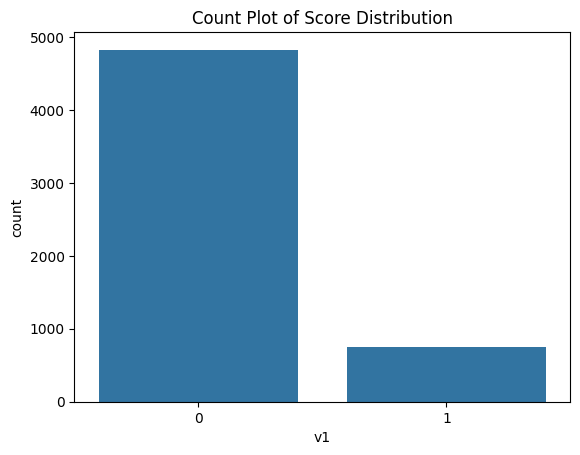

In [9]:
sns.countplot(x="v1", data=df)
plt.title("Count Plot of Score Distribution")
plt.xlabel("v1")
plt.ylabel("count")
plt.show()


In [10]:
from sklearn.utils import resample

df_majority = df[df['v1']==0]
df_minority = df[df['v1']==1]
print(df_majority.shape, df_minority.shape)


(4825, 2) (747, 2)


In [11]:
df_majority_downsampled = resample(df_majority, 
                                 replace=False,   
                                 n_samples=len(df_minority),    
                                 random_state=42)
df_resampled = pd.concat([df_majority_downsampled, df_minority])
df_resampled.reset_index(inplace = True)
df_resampled.drop('index', inplace=True,axis = 1)
df_resampled.head()

,v1,v2
0,0,"I am late,so call you tomorrow morning.take ca..."
1,0,U r too much close to my heart. If u go away i...
2,0,Wait &lt;#&gt; min..
3,0,Can you call me plz. Your number shows out of ...
4,0,MAYBE IF YOU WOKE UP BEFORE FUCKING 3 THIS WOU...


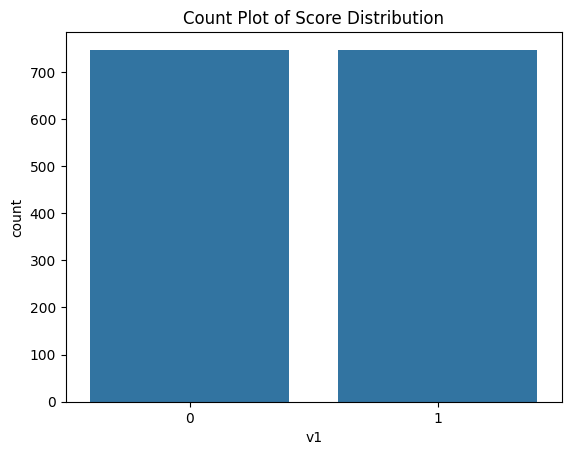

In [12]:
sns.countplot(x="v1", data=df_resampled)
plt.title("Count Plot of Score Distribution")
plt.xlabel("v1")
plt.ylabel("count")
plt.show()


In [13]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(df_resampled, test_size=0.2, random_state=42)
train_data, val_data = train_test_split(train_data, test_size=0.2, random_state=42)

In [14]:
from nltk.corpus import stopwords
from string import punctuation
import nltk
import re
from nltk.stem import WordNetLemmatizer

nltk.download('punkt_tab')      
nltk.download('wordnet')    
nltk.download('omw-1.4') 
nltk.download('averaged_perceptron_tagger_eng')
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [15]:
def clean_text_pipeline(text):
    """
    Cleans a single text string: lowercases, removes special chars, 
    removes stopwords, and lemmatizes.
    """
    # 1. Convert to lowercase
    text = str(text).lower()
    
    # 2. Remove special characters (keep only alphanumeric and whitespace)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    
    # 3 & 4. Tokenize (split), remove stopwords, and lemmatize
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    # Rejoin the words back into a single string
    return ' '.join(cleaned_words)

def clean_dataset(df, text_column):
    """
    Takes a dataframe and the name of the text column, applies the cleaning 
    pipeline, and returns a new dataframe to prevent SettingWithCopy warnings.
    """
    # Create a copy so we don't accidentally modify the original data in-place
    df_clean = df.copy()
    df_clean[text_column] = df_clean[text_column].apply(clean_text_pipeline)
    return df_clean

text_col = 'v2' 

train_data_clean = clean_dataset(train_data, text_col)
val_data_clean = clean_dataset(val_data, text_col)
test_data_clean = clean_dataset(test_data, text_col)


In [16]:
train_data_clean.head()

,v1,v2
1143,1,pdatenow double min 1000 txts orange tariff la...
1155,1,hot live fantasy call 08707509020 20p per min ...
179,0,going thru different feelingwavering decision ...
134,0,thanks love torch bold
209,0,lay man let know missed thought great day send...


In [17]:
val_data_clean.head()

,v1,v2
164,0,ok thats great thanx lot
1026,1,free tone hope enjoyed new content text stop 6...
1086,1,guess ithis first time created web page wwwasj...
815,1,want 2 get laid tonight want real dogging loca...
1111,1,tried contact response offer new nokia fone ca...


In [18]:
test_data_clean.head()

,v1,v2
949,1,urgent important information o2 user today luc...
900,1,panasonic bluetoothhdset free nokia free motor...
1339,1,want new video handset 750 time network min un...
983,1,hi ur lookin 4 saucy daytime fun wiv busty mar...
958,1,09066362231 urgent mobile 07xxxxxxxxx 2000 bon...


In [19]:
positive = train_data_clean[train_data_clean['v1'] == 1]
positive_list = train_data_clean['v2'].tolist()

negative = train_data_clean[train_data_clean['v1'] == 0]
negative_list = train_data_clean['v2'].tolist()

positive_all = " ".join(train_data_clean['v2'])
negative_all = " ".join(train_data_clean['v2'])


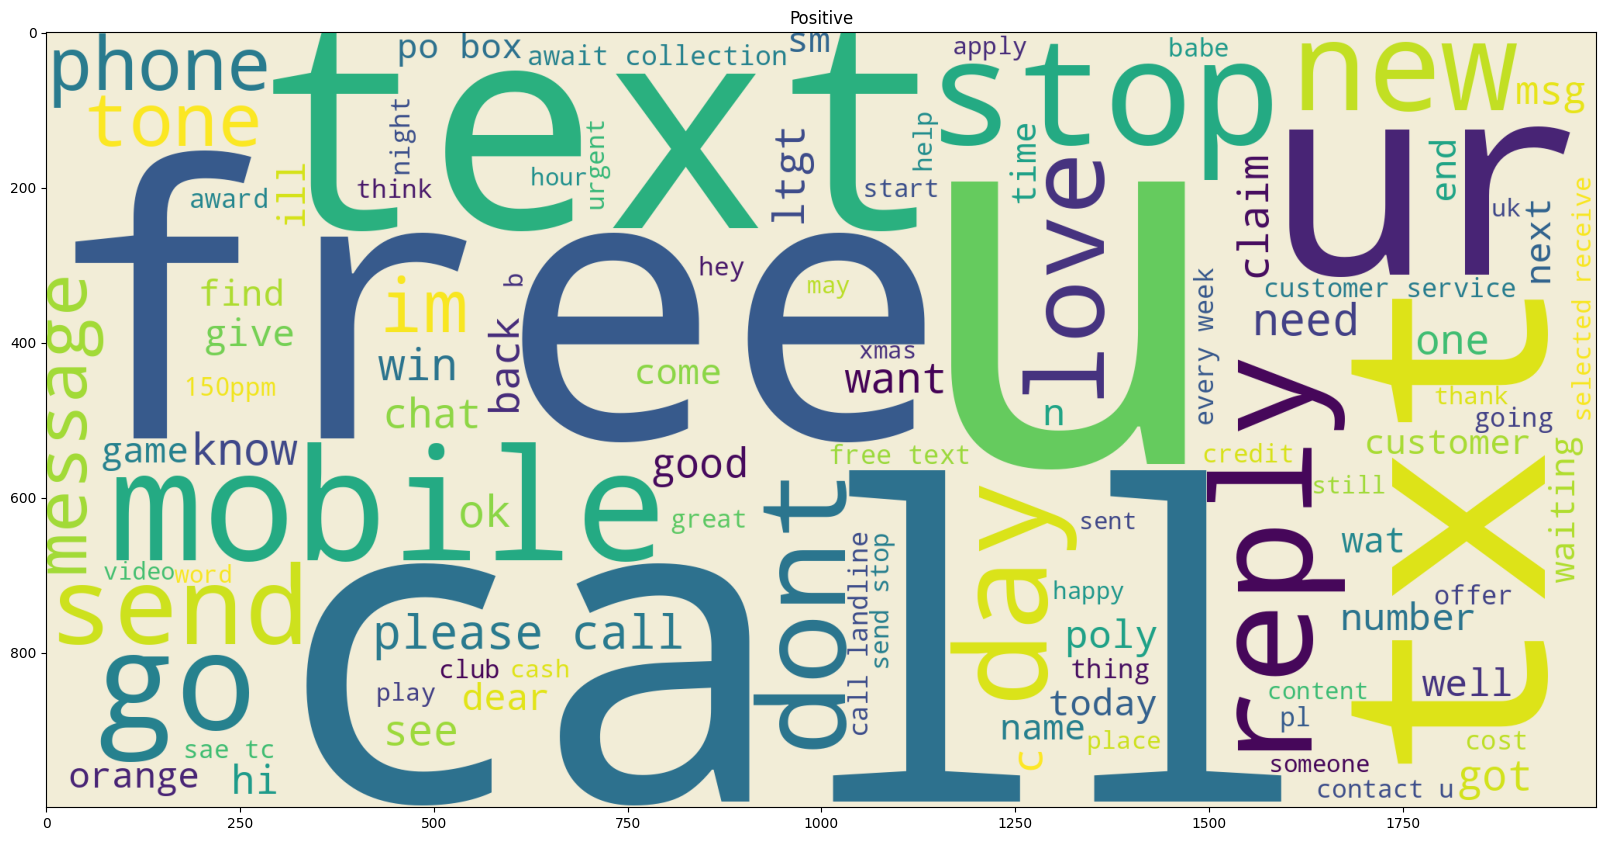

In [20]:
from wordcloud import WordCloud
WordCloud()
wordcloud = WordCloud(width=2000,
                      height=1000,
                      background_color='#F2EDD7FF',
                      max_words = 100).generate(positive_all)

plt.figure(figsize=(20,30))
plt.imshow(wordcloud)
plt.title("Positive")
plt.show()


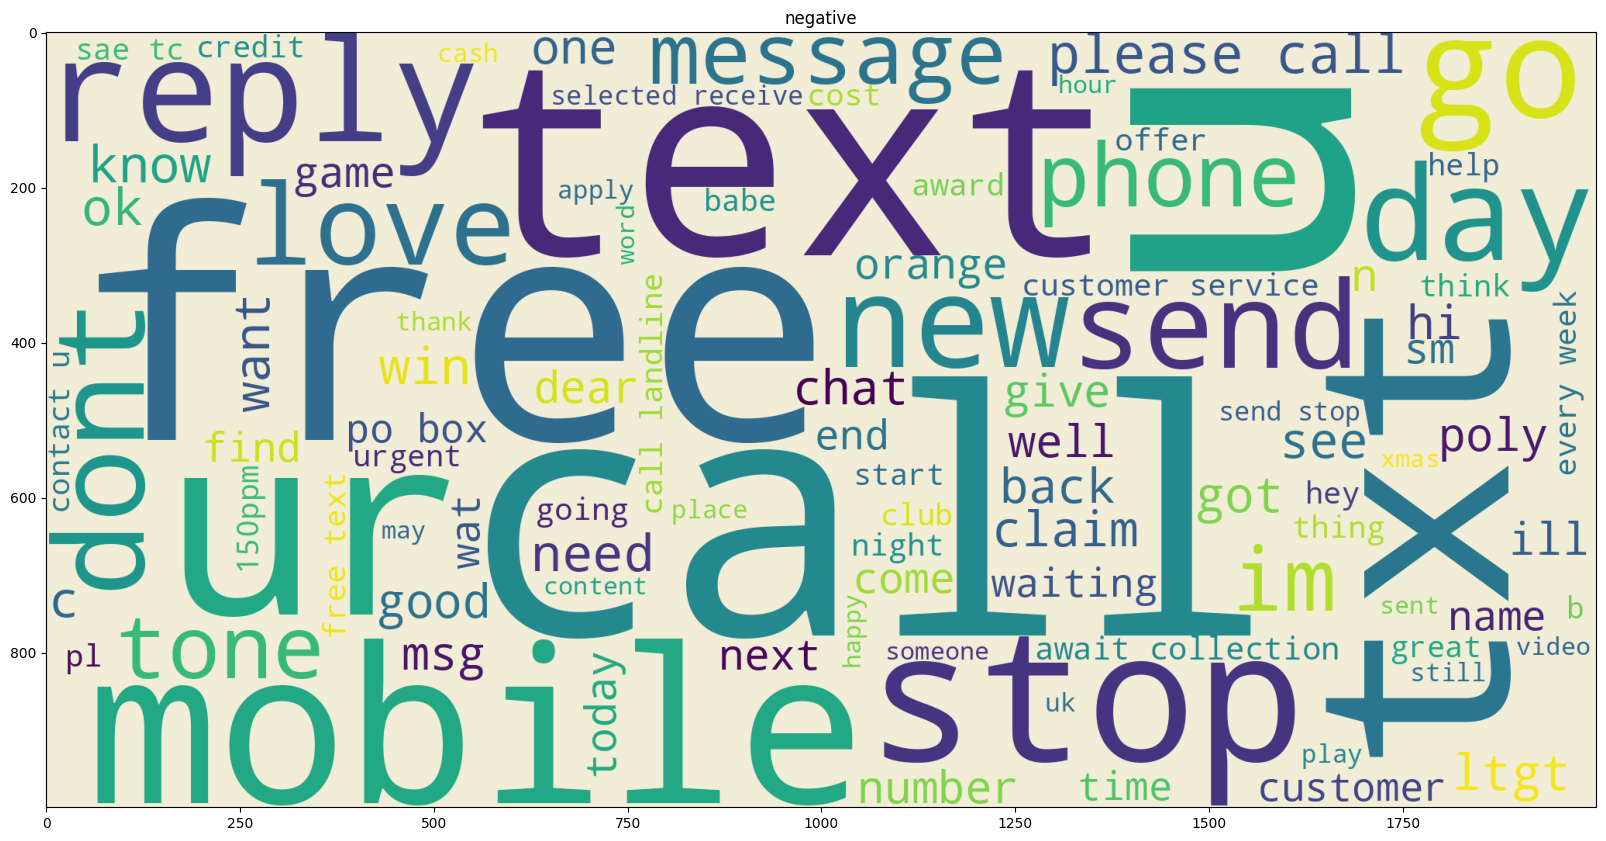

In [21]:
WordCloud()
wordcloud = WordCloud(width=2000,
                      height=1000,
                      background_color='#F2EDD7FF',
                      max_words = 100).generate(negative_all)

plt.figure(figsize=(20,30))
plt.imshow(wordcloud)
plt.title("negative")
plt.show()


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(train_data_clean['v2'])
y_train = train_data_clean['v1']

X_val = vectorizer.transform(val_data_clean['v2'])
y_val = val_data_clean['v1']

X_test = vectorizer.transform(test_data_clean['v2'])
y_test = test_data_clean['v1']

In [23]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


# 3. Initialize and Train the Naive Bayes Model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# 4. Predict on the Validation Set
y_val_pred = nb_model.predict(X_val)

# 5. Evaluate the Baseline
print("--- Baseline Naive Bayes Performance (Validation Set) ---")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_val_pred))

--- Baseline Naive Bayes Performance (Validation Set) ---
Accuracy: 0.9247

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93       120
           1       0.95      0.89      0.92       119

    accuracy                           0.92       239
   macro avg       0.93      0.92      0.92       239
weighted avg       0.93      0.92      0.92       239



In [24]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# 1. Build a Pipeline
# This links the vectorizer and the classifier together so they act as one unit
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', MultinomialNB())
])

# 2. Define the Parameter Grid
# The dictionary keys must use the step name (e.g., 'tfidf'), 
# followed by TWO underscores, followed by the parameter name.
param_grid = {
    # Test unigrams alone, unigrams + bigrams, and unigrams + bigrams + trigrams
    'tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
    
    # Test ignoring words that appear in more than 50%, 75%, or 100% of the documents
    'tfidf__max_df': [0.5, 0.75, 1.0],
    
    # Test different smoothing parameters for Naive Bayes
    'nb__alpha': [0.1, 0.5, 1.0] 
}

# 3. Initialize GridSearchCV
# cv=5 means 5-fold cross-validation
# n_jobs=-1 uses all your computer's CPU cores to run tests in parallel
# scoring='f1' tells it to optimize for the F1-score rather than raw accuracy
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, 
    n_jobs=-1, 
    scoring='f1', 
    verbose=1
)

# 4. Execute the Search (Fit on training data)
print("Starting grid search... this might take a minute.")
grid_search.fit(train_data_clean['v2'], y_train)

# 5. Output the Winners
print("\n--- Grid Search Results ---")
print(f"Best Parameters found: {grid_search.best_params_}")
print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

# 6. Evaluate the Best Model on Validation Data
best_model = grid_search.best_estimator_
y_val_pred_best = best_model.predict(val_data_clean['v2'])

print("\n--- Best Model Validation Performance ---")
print(classification_report(y_val, y_val_pred_best))

Starting grid search... this might take a minute.
Fitting 5 folds for each of 27 candidates, totalling 135 fits

--- Grid Search Results ---
Best Parameters found: {'nb__alpha': 0.5, 'tfidf__max_df': 0.5, 'tfidf__ngram_range': (1, 3)}
Best Cross-Validation F1-Score: 0.9398

--- Best Model Validation Performance ---
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       120
           1       0.96      0.90      0.93       119

    accuracy                           0.93       239
   macro avg       0.93      0.93      0.93       239
weighted avg       0.93      0.93      0.93       239

